---
#Atividade Avaliativa B2.1
---

In [9]:
#--------------------------------------------------------#
# Ygor Dassaev Lins Soares Barbosa
# Engenharia Ambiental e Sanitaria
# 27/05/26
# Atividade Avaliativa B2.1
#--------------------------------------------------------#

---
## Volume pluviometrico total do estado de Alagoas
---

In [10]:

import pandas as pd
import matplotlib.pyplot as plt

banco_de_dados = pd.read_csv('chuvas_AL_2023.csv', sep = ';')
banco_de_dados = banco_de_dados.drop(columns=['Unnamed: 0'])

alagoas_volume_total_precipitacao_junho = banco_de_dados['JUN'].sum()

print(f"Volume pluviometrico total mês de junho: {alagoas_volume_total_precipitacao_junho:,.2f} mm")



Volume pluviometrico total mês de junho: 17,785.00 mm


---
## Volume pluviometrico médio do estado de Alagoas no mês de Janeiro
---

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

banco_de_dados = pd.read_csv('chuvas_AL_2023.csv', sep = ';')
banco_de_dados = banco_de_dados.drop(columns=['Unnamed: 0'])

alagoas_media_pluviometrica = banco_de_dados['JAN'].mean()

print(f"Volume médio pluviométrica do mês de janeiro: {alagoas_media_pluviometrica:,.2f} mm")


Volume médio pluviométrica do mês de janeiro: 72.19 mm


---
## Municipio com maior Indice pluviometrico e Municipio com menor indice pluviometrico
---

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

banco_de_dados = pd.read_csv('chuvas_AL_2023.csv', sep = ';')
banco_de_dados = banco_de_dados.drop(columns=['Unnamed: 0'])

Municipio_maior_indice_Pluviometrico = banco_de_dados.loc[banco_de_dados['FEV'].idxmax()]

print(f"Municipio com maior indice pluviometrico: {Municipio_maior_indice_Pluviometrico['MUNICIPIO']}")

Municipio_menor_indice_Pluviometrico = banco_de_dados.loc[banco_de_dados['FEV'].idxmin()]

print(f"Municipio com menor indice pluviometrico: {Municipio_menor_indice_Pluviometrico['MUNICIPIO']}")


Municipio com maior indice pluviometrico: Joaquim Gomes
Municipio com menor indice pluviometrico: Delmiro Gouveia 


---
##Grafico de linhas continuas do volume pluviometrico anual do municipio de Colonia Leopoldina
---

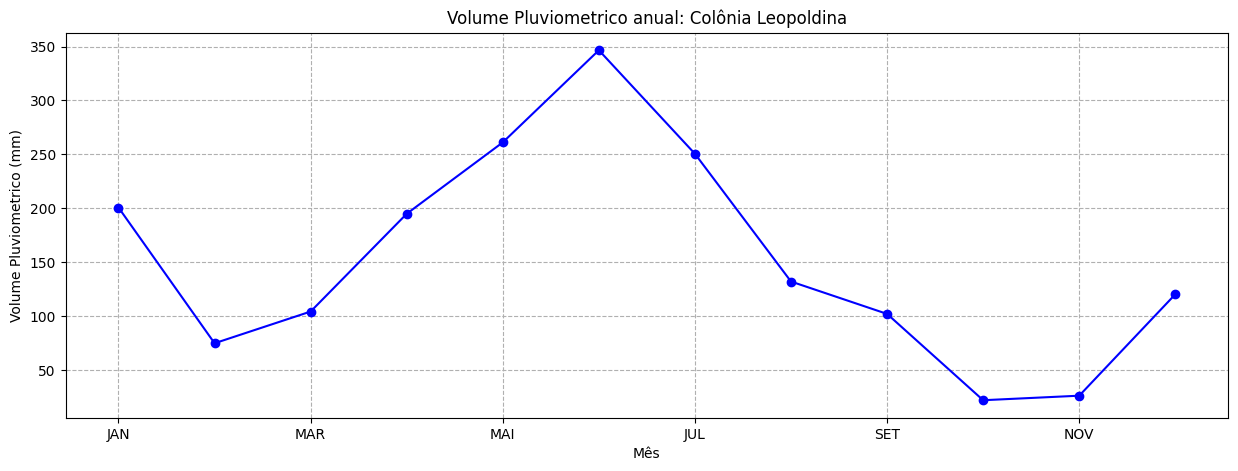

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

banco_de_dados = pd.read_csv('chuvas_AL_2023.csv', sep = ';')
banco_de_dados = banco_de_dados.drop(columns=['Unnamed: 0'])

municipio_alvo = 'Colônia Leopoldina'

df_temporal = banco_de_dados.set_index('MUNICIPIO')

df_temporal.loc[municipio_alvo].plot(kind = 'line', marker = 'o', figsize = (15, 5), color = 'blue')

plt.title(f"Volume Pluviometrico anual: {municipio_alvo}")
plt.xlabel("Mês")
plt.ylabel("Volume Pluviometrico (mm)")
plt.grid(True, linestyle = '--')
plt.show()

---
##Gráfico de barra horizontal Exibindo os 5 municipios com os maiores indices pluviometricos
---

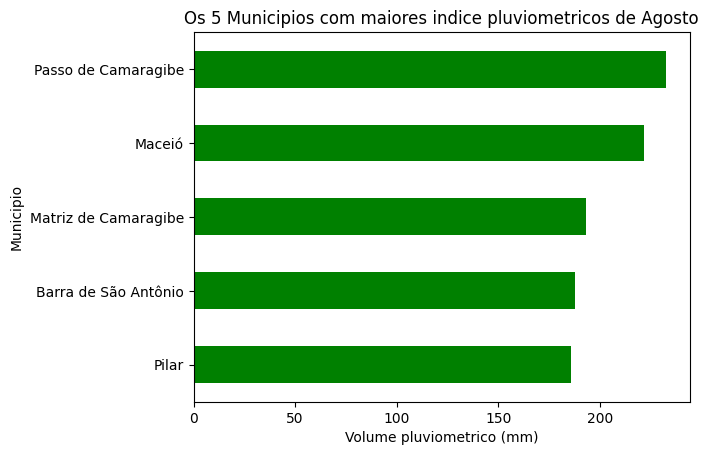

In [14]:

banco_de_dados = pd.read_csv('chuvas_AL_2023.csv', sep = ';')
banco_de_dados = banco_de_dados.drop(columns=['Unnamed: 0'])

Municipio_maior_indice_Pluviometrico = banco_de_dados.sort_values(by='AGO', ascending = False).head(5)

Municipio_maior_indice_Pluviometrico.plot(kind = 'barh', x = 'MUNICIPIO', y = 'AGO', color = 'green', legend = False)

plt.title("Os 5 Municipios com maiores indice pluviometricos de Agosto")
plt.xlabel("Volume pluviometrico (mm)")
plt.ylabel("Municipio")
plt.gca().invert_yaxis()
plt.show()


---
##Graficos de barras dos meses de Janeiro, Junho e Novembro
---

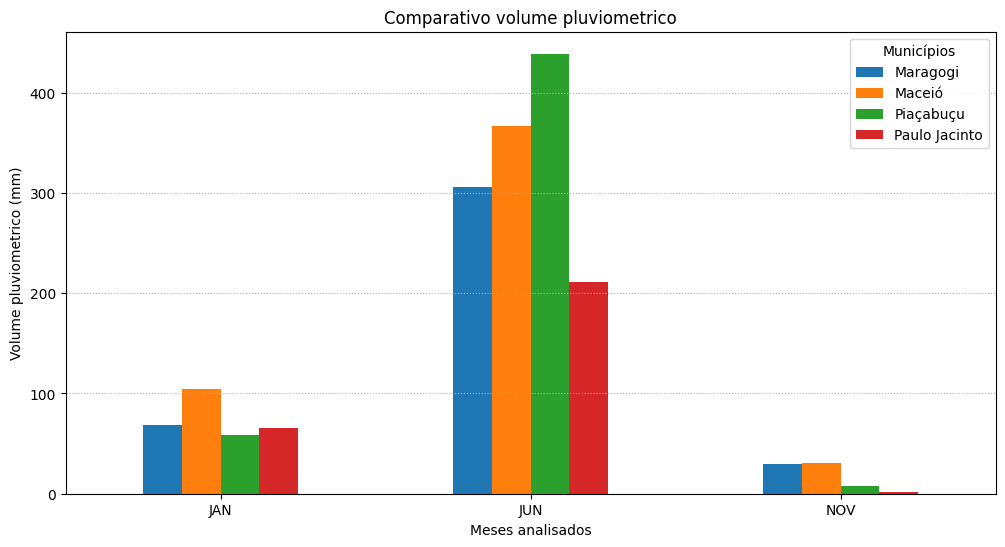

In [15]:

import matplotlib.pyplot as plt

cidades_comparacao = ["Maragogi", "Maceió", "Piaçabuçu", "Paulo Jacinto"]

anos_recorte = ['JAN', 'JUN', 'NOV']

df_filtrado = df_temporal.loc[cidades_comparacao, anos_recorte]

df_filtrado.T.plot(kind='bar', figsize=(12, 6))

plt.title("Comparativo volume pluviometrico")
plt.xlabel("Meses analisados")
plt.ylabel("Volume pluviometrico (mm)")
plt.xticks (rotation=0) # Mantém os anos na horizontal para melhor leitura
plt.grid(axis='y', linestyle=':')
plt.legend(title="Municípios")
plt.show()


---
##Grafico Interativo
---

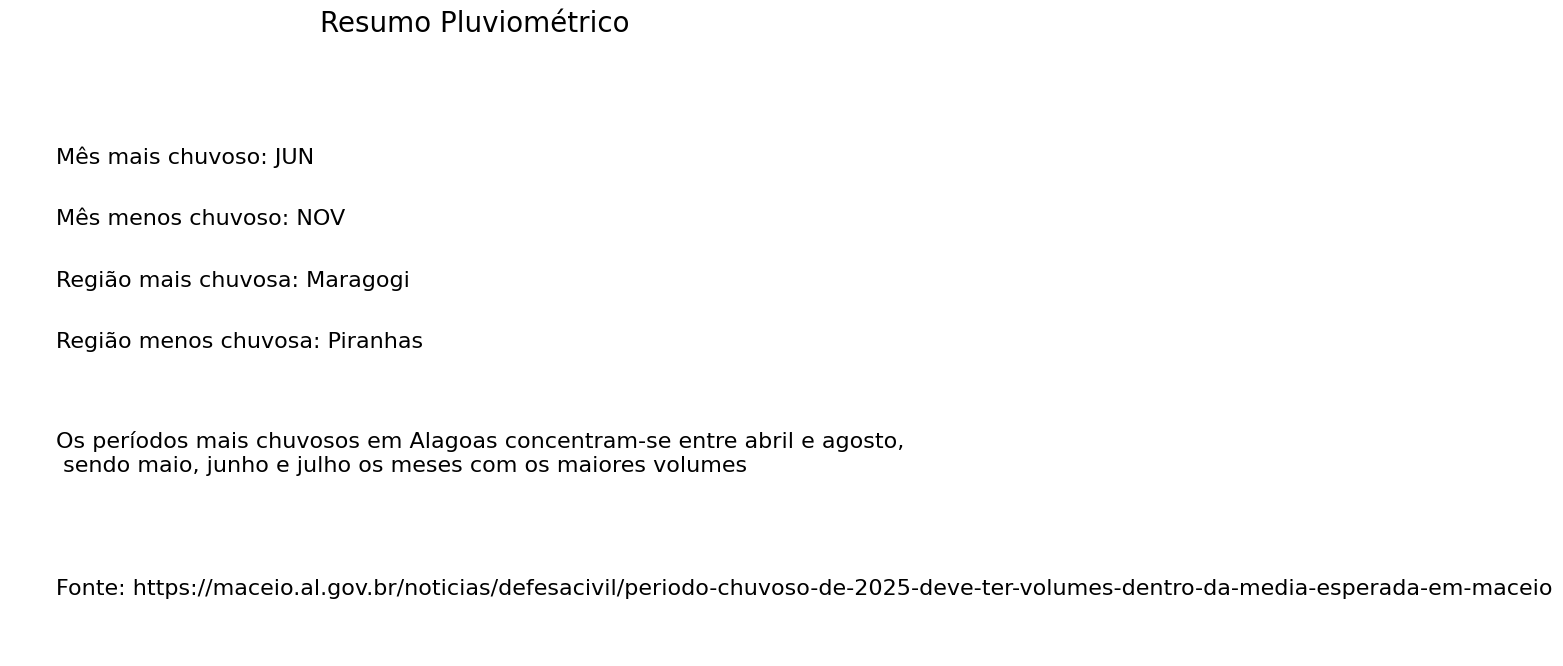

In [16]:
import plotly.express as px

cidades_comparacao = ["Maragogi", "União dos Palmares", "Batalha", "Piranhas"]

df_filtrado = df_temporal.loc[cidades_comparacao]

df_comparacao_temporal = df_filtrado.T

figura_interativa = px.line(df_comparacao_temporal, markers = True, title = "Analise comparativa do volume pluviometrico anual",
labels = {
    "index": "Mês",
    "value": "Volume pluviometrico (mm)",
    "variable": "Meses",
})

figura_interativa.show()

print("\n\n")

soma_Pluviometria_mensal = df_filtrado.sum()
Mes_maior_indice_Pluviometrico = soma_Pluviometria_mensal.idxmax()
Mes_menor_indice_Pluviometrico = soma_Pluviometria_mensal.idxmin()

soma_municipios = df_filtrado.sum(axis=1)
municipio_menor = soma_municipios.idxmin()
municipio_maior = soma_municipios.idxmax()

plt.figure(figsize=(12,8))

plt.text(
    0.05, 0.80,
    f"Mês mais chuvoso: {Mes_maior_indice_Pluviometrico}",
    fontsize=16
)

plt.text(
    0.05, 0.70,
    f"Mês menos chuvoso: {Mes_menor_indice_Pluviometrico}",
    fontsize=16
)

plt.text(
    0.05, 0.60,
    f"Região mais chuvosa: {municipio_maior}",
    fontsize=16
)

plt.text(
    0.05, 0.50,
    f"Região menos chuvosa: {municipio_menor}",
    fontsize=16
)

plt.text(
    0.05, 0.30,
    f"Os períodos mais chuvosos em Alagoas concentram-se entre abril e agosto, \n sendo maio, junho e julho os meses com os maiores volumes",
    fontsize = 16

)

plt.text(
    0.05, 0.10,
    f"Fonte: https://maceio.al.gov.br/noticias/defesacivil/periodo-chuvoso-de-2025-deve-ter-volumes-dentro-da-media-esperada-em-maceio",
    fontsize = 16
)

plt.axis('off')
plt.title("Resumo Pluviométrico", fontsize=20)
plt.show()
